In [68]:
import torch

ckpt = torch.load(checkpoint_path, map_location="cpu")
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

def dump_dict(d, prefix=""):
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            print(f"{name}/")
            dump_dict(v, prefix=name + ".")
        elif torch.is_tensor(v):
            print(f"{name:60s} | shape={tuple(v.shape)} | dtype={v.dtype}")
        else:
            print(f"{name:60s} | type={type(v)}")

dump_dict(state["model"] if isinstance(state, dict) and "model" in state else state)

nets/
nets.policy.core.rnn_cell.gleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.vleak                              | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.cm                                 | shape=(64,) | dtype=torch.float32
nets.policy.core.rnn_cell.sigma                              | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.mu                                 | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.w                                  | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.erev                               | shape=(64, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_sigma                      | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_mu                         | shape=(19, 64) | dtype=torch.float32
nets.policy.core.rnn_cell.sensory_w                          | shape=(19, 64) | dtype=torch.float32
net

Loading model from /work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth ...
Quantized w Non-zero PTQ: sparsity=88.11% (non-zero 487/4096)


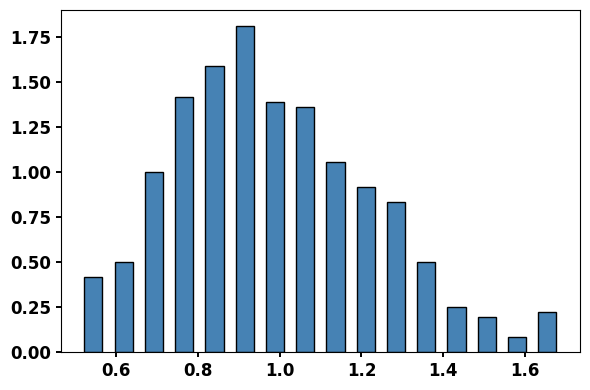

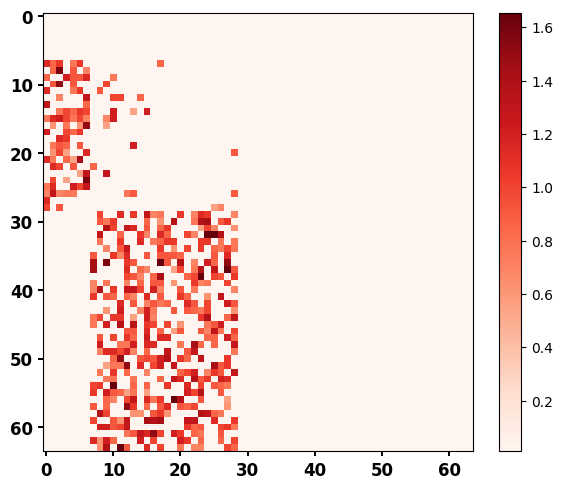

Quantized w_rev Non-zero PTQ: sparsity=88.18% (non-zero 484/4096)


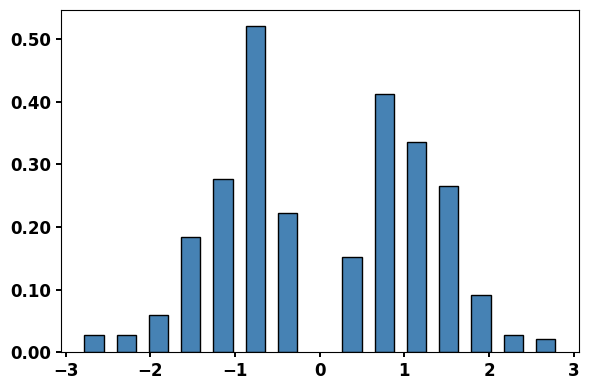

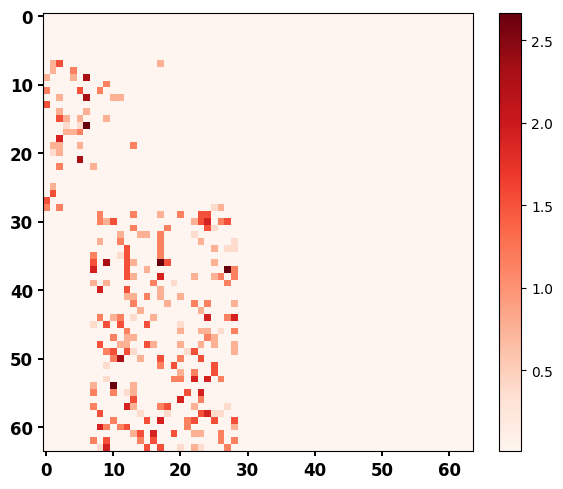

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch.nn.functional as F

# ------------------------------------------------------------------
# ユーティリティ関数
# ------------------------------------------------------------------
def flatten_dict(d, prefix=""):
    flat = {}
    for k, v in d.items():
        name = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_dict(v, prefix=name + "."))
        else:
            flat[name] = v
    return flat

def find_key_endswith(flat_dict, suffix):
    for k in flat_dict.keys():
        if k.endswith(suffix):
            return k
    return None

# ------------------------------------------------------------------
# 非ゼロ PTQ
# ------------------------------------------------------------------
def ptq_weight_nonzero(self, params: torch.Tensor, n_bits: int = 8, percentile: float = 0.99, symmetric: bool = True):
    """
    Sparse weights PTQ:
    - Only non-zero elements are quantized
    - Zero is preserved
    - symmetric=True  : signed symmetric quantization
    - symmetric=False : unsigned asymmetric quantization
    """
    assert n_bits >= 2
    if percentile > 1.0:
        percentile /= 100.0

    with torch.no_grad():
        x = params.to(torch.float32)
        nz_mask = x != 0
        nz = x[nz_mask]
        if nz.numel() == 0:
            return params

        if symmetric:
            # abs ベースの片側クリップ（上側のみで十分）
            q = torch.quantile(nz.abs(), percentile)
            nz_clipped = nz.clamp(min=-q, max=q)
        else:
            # 両側クリップ（下側/上側をパーセンタイルで切る）
            low = torch.quantile(nz, 1.0 - percentile)
            high = torch.quantile(nz, percentile)
            nz_clipped = nz.clamp(min=low, max=high)

        if symmetric:
            qmax = 2 ** (n_bits - 1) - 1
            abs_max = nz_clipped.abs().max()
            if abs_max < 1e-12:
                return params
            scale = abs_max / qmax
            nz_q = torch.round(nz_clipped / scale).clamp(-qmax, qmax) * scale
        else:
            qmax = 2 ** n_bits - 1
            min_val = nz_clipped.min()
            max_val = nz_clipped.max()
            if max_val - min_val < 1e-12:
                return params
            scale = (max_val - min_val) / qmax
            nz_q = torch.round((nz_clipped - min_val) / scale).clamp(0, qmax) * scale + min_val

        out = x.clone()
        out[nz_mask] = nz_q
        params.copy_(out.to(params.dtype))

    return params

# ------------------------------------------------------------------
# プロット関数
# ------------------------------------------------------------------
def plot_separated_stages(checkpoint_path: str, bins: int = 100):
    print(f"Loading model from {checkpoint_path} ...")
    state = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]

    flat = flatten_dict(state)

    w_key = find_key_endswith(flat, "rnn_cell.w")
    mask_key = find_key_endswith(flat, "rnn_cell.sparsity_mask")
    erev_key = find_key_endswith(flat, "rnn_cell.erev")

    if not (w_key and mask_key and erev_key):
        print("Error: 必要なパラメータが見つかりません。")
        return

    w_raw = flat[w_key]
    mask = flat[mask_key]
    erev = flat[erev_key]

    # ------------------------------------------------------------------
    # データ変換パイプライン
    # ------------------------------------------------------------------
    stages = [
#        ("Raw Weights (w)", w_raw),
#        ("Softplus (Positive)", F.softplus(w_raw)),
#        ("Masked (Softplus * mask)", F.softplus(w_raw) * mask),
#        ("Effective Rev (Masked * Erev)", F.softplus(w_raw) * mask * erev),
        ("Quantized w Non-zero PTQ", ptq_weight_nonzero(None, F.softplus(w_raw) * mask, n_bits=4, symmetric=False)),
        ("Quantized w_rev Non-zero PTQ", ptq_weight_nonzero(None, F.softplus(w_raw) * mask * erev, n_bits=4, symmetric=True)),
    ]

    # ------------------------------------------------------------------
    # 描画
    # ------------------------------------------------------------------
    tick_size = 12
    tick_width = 1.4
    tick_weight = "bold"

    # ------------------------------------------------------------------
    # 描画
    # ------------------------------------------------------------------
    for name, data in stages:
        flat_data = data.detach().cpu().numpy().flatten()
        nz_data = flat_data[flat_data != 0]
        mat_data = data.detach().cpu().numpy()
        zero_ratio = 1.0 - (len(nz_data) / len(flat_data))
        print(f"{name}: sparsity={zero_ratio*100:.2f}% (non-zero {len(nz_data)}/{len(flat_data)})")

        # 非ゼロのみヒストグラム（離散バーを太く）
        if len(nz_data) > 0:
            plt.figure(figsize=(6, 4))
            vals, counts = np.unique(nz_data, return_counts=True)
            if len(vals) > 1:
                step = np.min(np.diff(np.sort(vals)))
                width = step * 0.6
            else:
                width = 0.2
            plt.bar(vals, counts / counts.sum() / step, width=width, color="steelblue", edgecolor="black")
            ax = plt.gca()
            ax.tick_params(axis="both", labelsize=tick_size, width=tick_width)
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
            for lbl in ax.get_xticklabels() + ax.get_yticklabels():
                lbl.set_fontweight(tick_weight)
            plt.tight_layout()
            plt.show()
        else:
            print(f"{name} has no non-zero elements. Skip histogram.")

        # ヒートマップ
        plt.figure(figsize=(6, 5))
        abs_max = np.abs(mat_data).max()
        if abs_max == 0: abs_max = 1.0
        plt.imshow(mat_data, cmap="seismic", vmin=0.01, vmax=abs_max, aspect="auto", interpolation="nearest")
        plt.colorbar()
        ax = plt.gca()
        ax.tick_params(axis="both", labelsize=tick_size, width=tick_width)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            lbl.set_fontweight(tick_weight)
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------
# 実行
# ------------------------------------------------------------------
path = "/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth"
plot_separated_stages(path)


Total keys found: 130


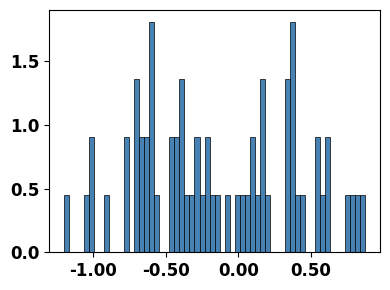

Sparsity mask or weights not found.
Total keys found: 130


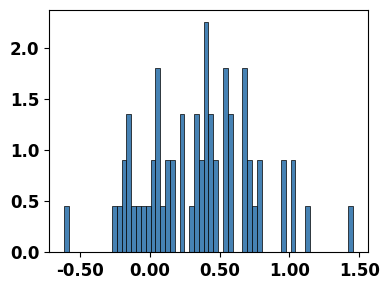

Sparsity mask or weights not found.
Total keys found: 130


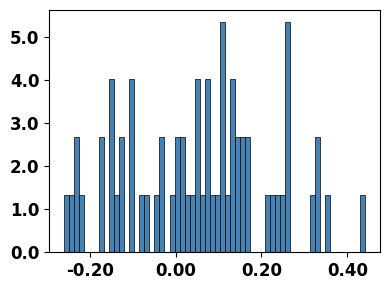

Sparsity mask or weights not found.


In [75]:
# Digital RRAM
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.cm"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.gleak"])
plot_params("/work/robomimic/bc_trained_models/lift/ncp-pure-best/ph/unit64/seed1/models/model_epoch_250_low_dim_v15_success_1.0.pth", include_keywords=["nets.policy.core.rnn_cell.vleak"])

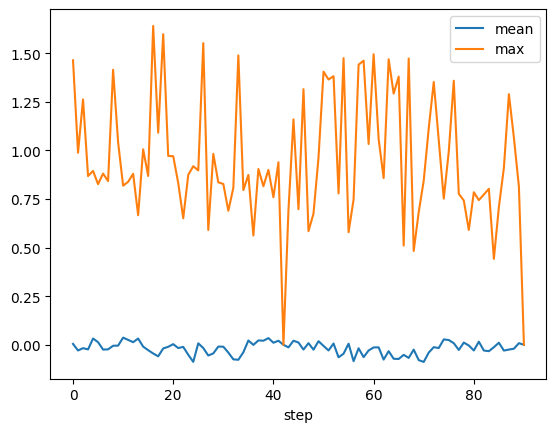

[-0.07651115208864212, 1.3405781984329224]
0.17229023575782776
edges range [-1.771, 1.640], bins=100


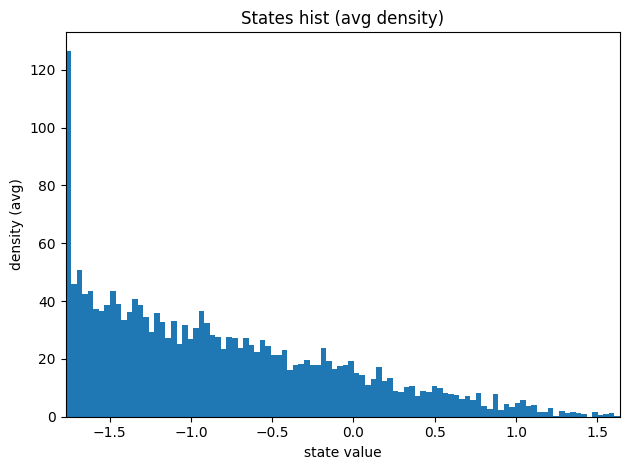

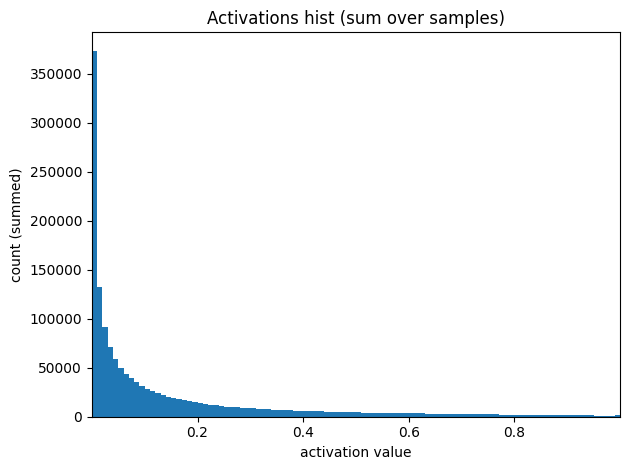

In [ ]:
import json, numpy as np, matplotlib.pyplot as plt

with open("/work/robomimic/quantize_logs/Weight/uunit128_8bit.json") as f:
    data = json.load(f)

if len(data) == 0:
    raise ValueError("data is empty")

means = [d["states"]["mean"] for d in data if "states" in d]
maxes = [d["states"]["max"] for d in data if "states" in d]

plt.plot(means, label="mean")
plt.plot(maxes, label="max")
plt.xlabel("step"); plt.legend(); plt.show()

# 先頭サンプル確認
print(data[0].get("mu_minmax"))
print(data[0].get("activations", {}).get("mean"))

# states ヒストを値レンジでプロット（等間隔binを復元）
states_hists = [np.array(d["states"]["hist"]) for d in data if "states" in d]
states_hist_sum = np.sum(states_hists, axis=0)
n_bins = len(states_hist_sum)
min_val = min(d["states"]["min"] for d in data if "states" in d)
max_val = max(d["states"]["max"] for d in data if "states" in d)
edges = np.linspace(min_val, max_val, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

plt.bar(centers, states_hist_sum, width=widths, align="center")
plt.xlabel("state value")
plt.ylabel("count (summed)")
plt.xlim(min_val, max_val)
plt.title("States hist (sum over samples)")
plt.tight_layout()
plt.show()

# activations も同様
act_hists = [np.array(d["activations"]["hist"]) for d in data if "activations" in d]
act_hist_sum = np.sum(act_hists, axis=0)
n_bins_act = len(act_hist_sum)
amin_val = min(d["activations"]["min"] for d in data if "activations" in d)
amax_val = max(d["activations"]["max"] for d in data if "activations" in d)
aedges = np.linspace(amin_val, amax_val, n_bins_act + 1)
acenters = 0.5 * (aedges[:-1] + aedges[1:])
awidths = np.diff(aedges)

plt.bar(acenters, act_hist_sum, width=awidths, align="center")
plt.xlabel("activation value")
plt.ylabel("count (summed)")
plt.xlim(amin_val, amax_val)
plt.title("Activations hist (sum over samples)")
plt.tight_layout()
plt.show()

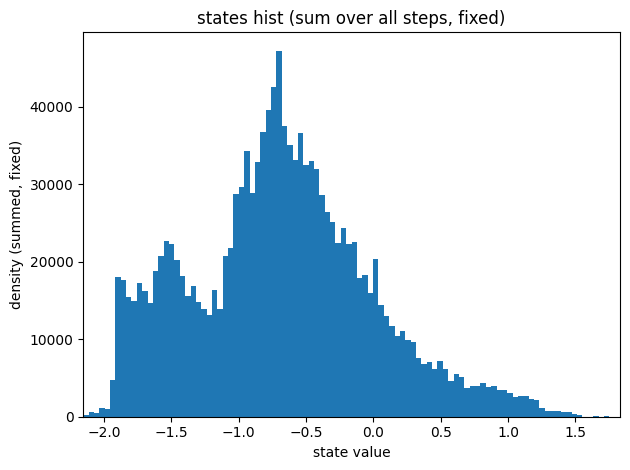

In [62]:
import json, numpy as np, matplotlib.pyplot as plt

json_path = "/work/robomimic/quantize_logs/Weight/uunit128_2bit.json"
with open(json_path) as f:
    data = json.load(f)

if not data:
    raise ValueError("data is empty")

def plot_states_all_sum_fixed(data, n_bins=100):
    # 各ステップの hist を共通の bin にリサンプリングして合算
    all_mins = []
    all_maxs = []
    for d in data:
        st = d.get("states", {})
        hist = np.array(st.get("hist", []), dtype=float)
        if hist.size == 0:
            continue
        all_mins.append(st.get("min", -2.0))
        all_maxs.append(st.get("max", 2.0))
    
    if not all_mins:
        print("states hist is empty")
        return

    # 全体の min/max を決定
    vmin, vmax = min(all_mins), max(all_maxs)
    edges_common = np.linspace(vmin, vmax, n_bins + 1)
    hist_sum = np.zeros(n_bins)

    # 各ステップを共通 bin に補間
    for d in data:
        st = d.get("states", {})
        hist = np.array(st.get("hist", []), dtype=float)
        if hist.size == 0:
            continue
        step_min = st.get("min", -2.0)
        step_max = st.get("max", 2.0)
        edges_step = np.linspace(step_min, step_max, len(hist) + 1)
        centers_step = 0.5 * (edges_step[:-1] + edges_step[1:])
        
        for c, h, w in zip(centers_step, hist, np.diff(edges_step)):
            if w == 0:
                # 幅が0の場合はそのまま加算
                idx = np.searchsorted(edges_common, c, side='right') - 1
                if 0 <= idx < n_bins:
                    hist_sum[idx] += h
            else:
                idx = np.searchsorted(edges_common, c, side='right') - 1
                if 0 <= idx < n_bins:
                    hist_sum[idx] += h / w


    # プロット
    centers_common = 0.5 * (edges_common[:-1] + edges_common[1:])
    widths_common = np.diff(edges_common)
    plt.bar(centers_common, hist_sum, width=widths_common, align="center")
    plt.xlabel("state value")
    plt.ylabel("density (summed, fixed)")
    plt.title("states hist (sum over all steps, fixed)")
    plt.xlim(vmin, vmax)
    plt.tight_layout()
    plt.show()

plot_states_all_sum_fixed(data, n_bins=100)
